<a href="https://colab.research.google.com/github/nishasn10/E-Learning_Final/blob/main/E_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


        DATASET INFORMATION
Student Dataset Shape: (500, 11)
Course Dataset Shape: (20, 7)
Interaction Dataset Shape: (4519, 6)

========== STUDENT DATA ==========
  student_id  age education_level  study_hours  previous_score  quiz_score  \
0      S0001   24              UG            3              45          68   
1      S0002   21              UG            6              76          49   
2      S0003   22         Diploma            6              99          51   
3      S0004   24              UG            3              87          69   
4      S0005   20              UG            7              52          80   

   assignment_score  completion_rate  courses_completed  \
0                53               54                  5   
1                75               44                  3   
2                72               58                 11   
3                62               60                  0   
4                89               71                  7   

           

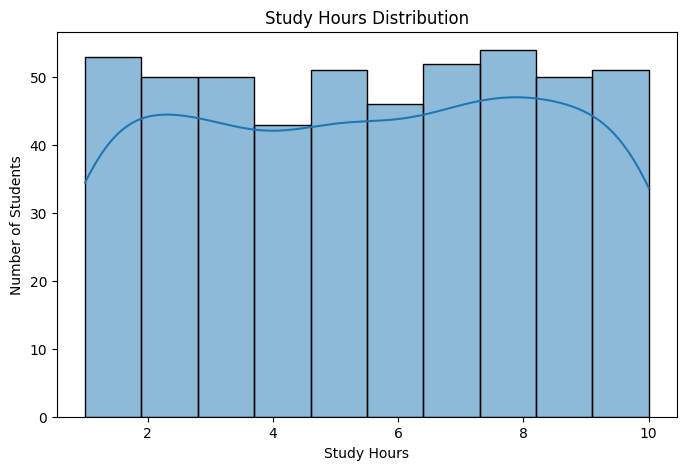

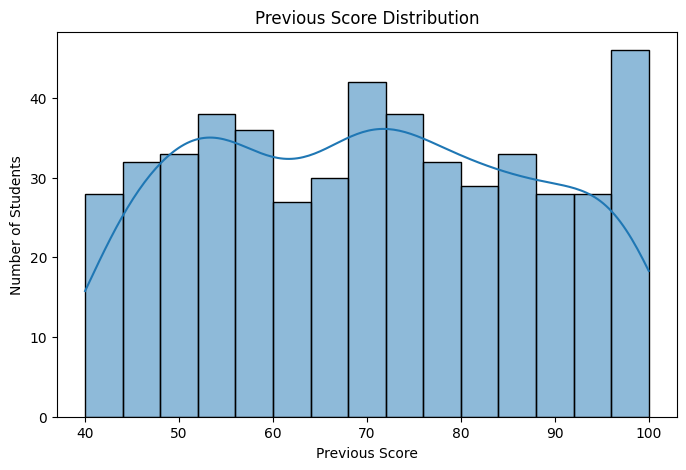

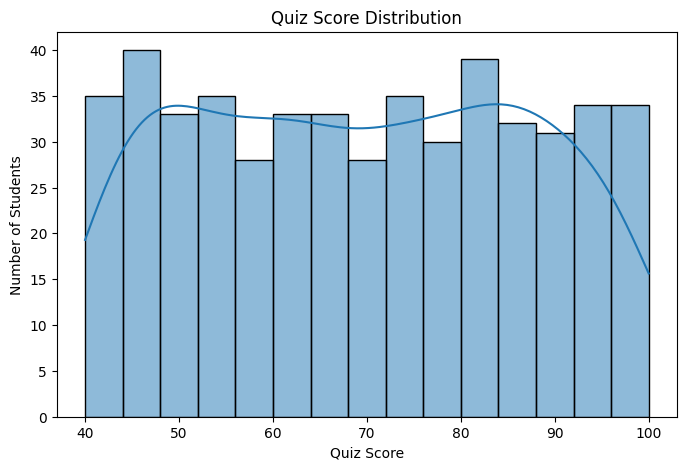

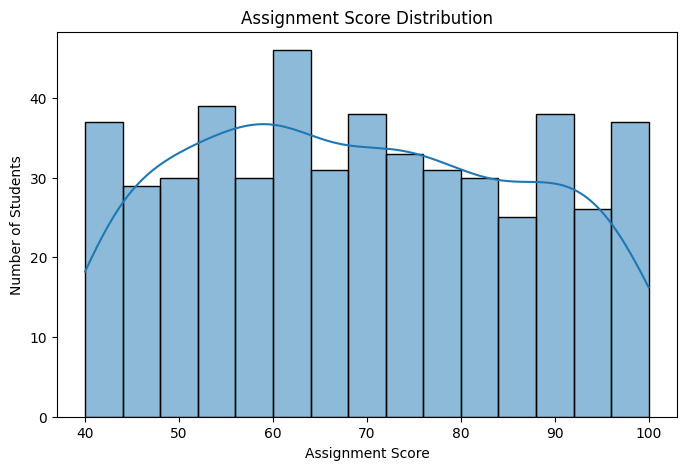

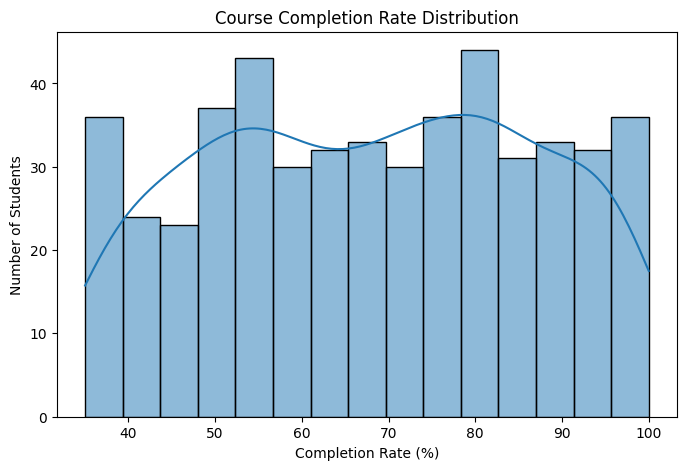

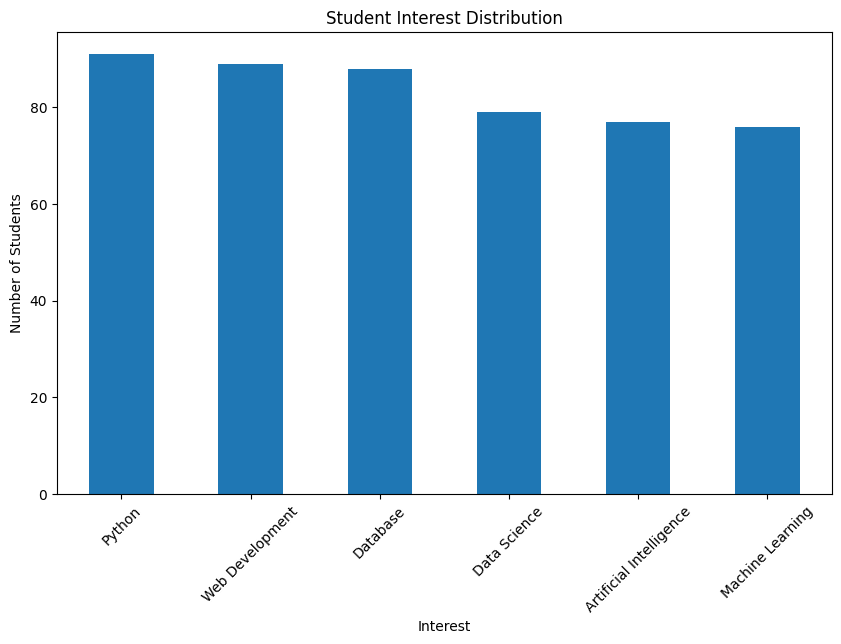

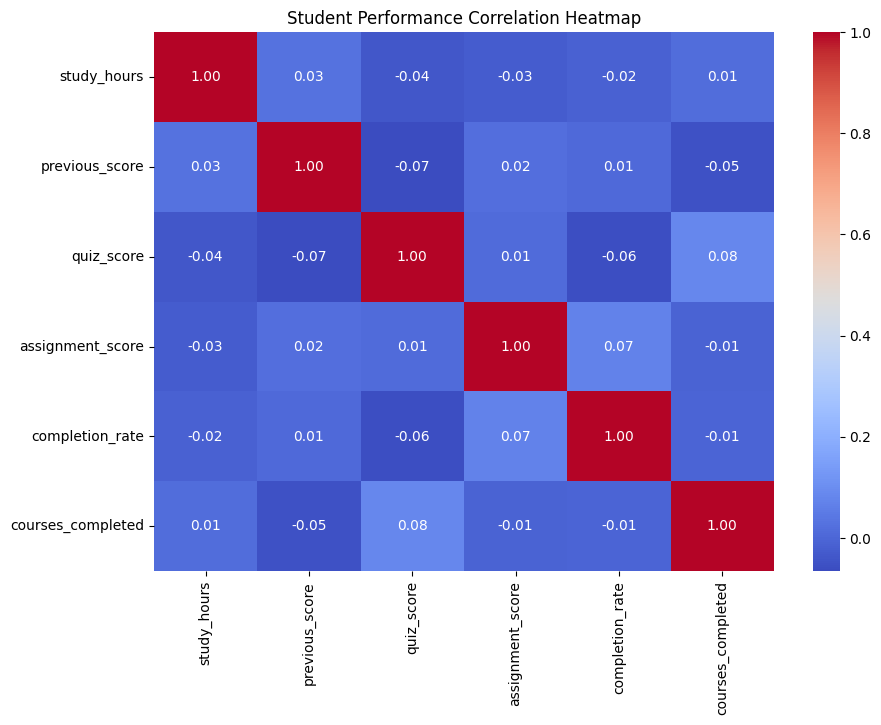

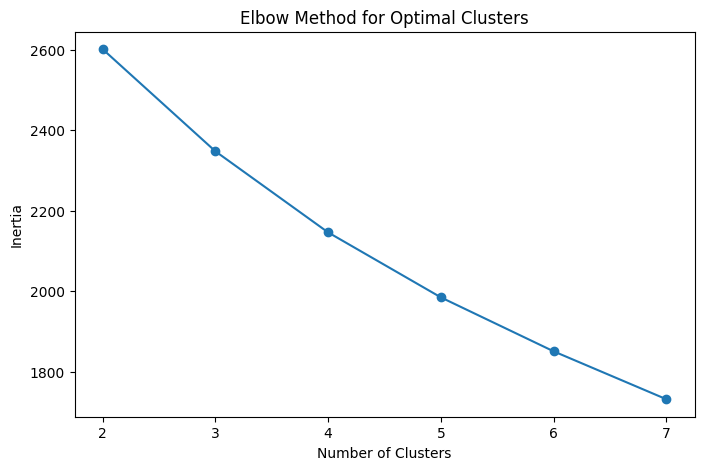


K-Means Silhouette Score: 0.122

========== CLUSTER SUMMARY ==========
         study_hours  previous_score  quiz_score  assignment_score  \
cluster                                                              
0           5.570552       87.073620   58.950920         67.957055   
1           5.306358       53.843931   63.653179         71.317919   
2           5.707317       70.054878   85.347561         67.652439   

         completion_rate  courses_completed  
cluster                                      
0              70.049080           5.717791  
1              69.479769           5.549133  
2              64.634146          10.518293  


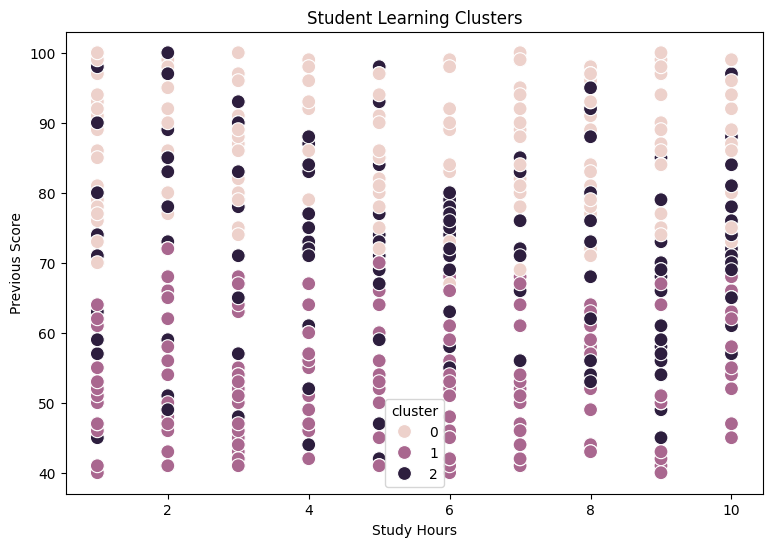

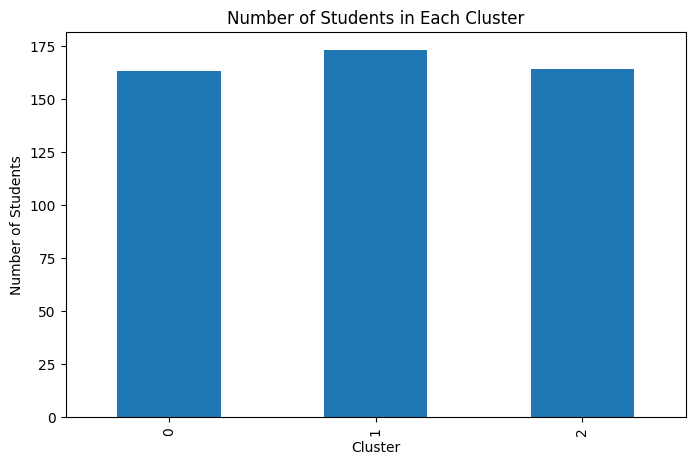

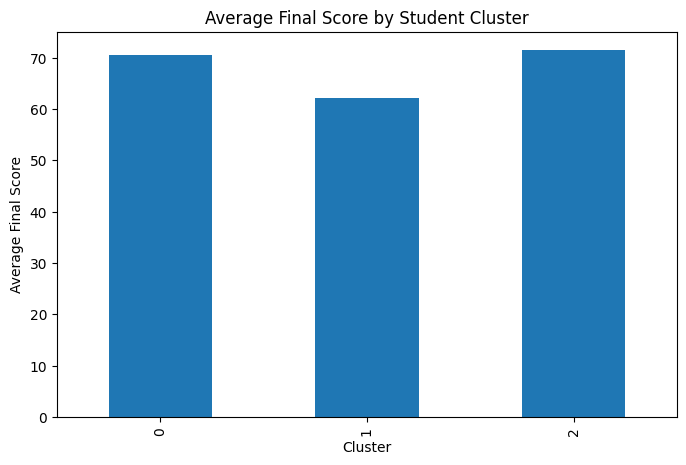


       RANDOM FOREST PERFORMANCE
MAE: 2.1
RMSE: 2.525
R2 Score: 0.916


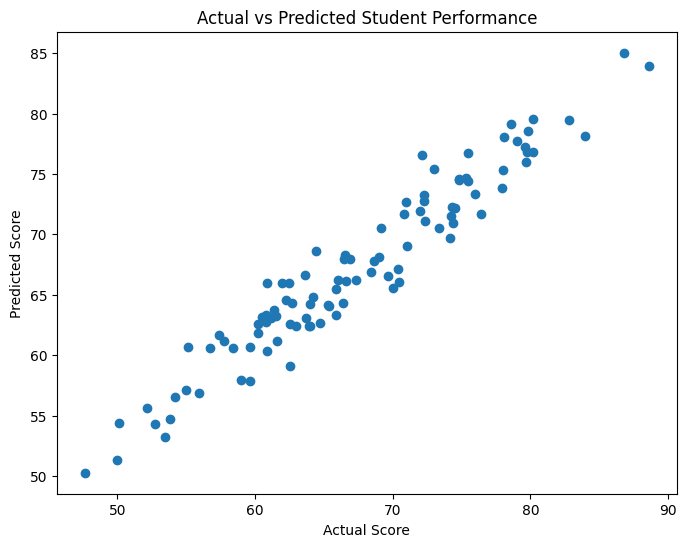


========== FEATURE IMPORTANCE ==========
             Feature  Importance
1     previous_score    0.383172
3   assignment_score    0.250883
2         quiz_score    0.243690
0        study_hours    0.066802
4    completion_rate    0.042099
5  courses_completed    0.013355


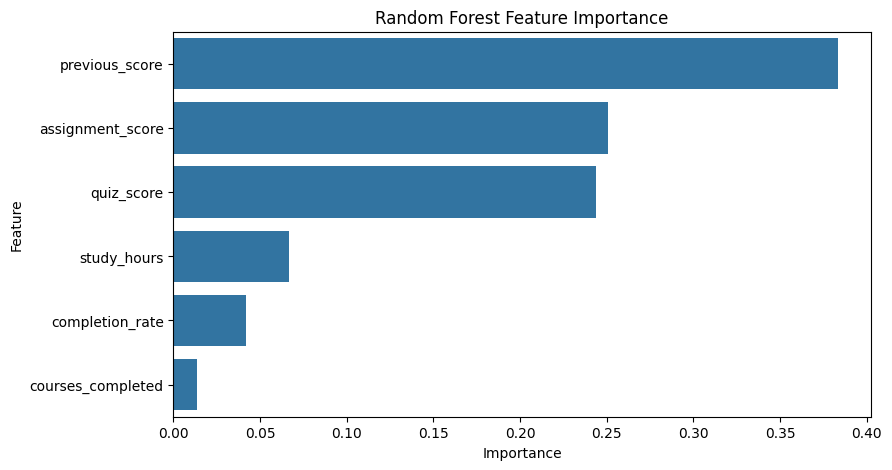


TF-IDF Matrix Shape: (20, 114)
Cosine Similarity Matrix Shape: (20, 20)

========== SIMILAR COURSES ==========
               course_name                 category    difficulty  rating  \
0        Statistics for ML         Machine Learning  Intermediate     4.7   
1            Deep Learning         Machine Learning      Advanced     4.7   
2             Data Science             Data Science  Intermediate     4.6   
3  Artificial Intelligence  Artificial Intelligence      Advanced     4.8   
4          Computer Vision  Artificial Intelligence      Advanced     4.6   

   similarity  
0       0.429  
1       0.402  
2       0.195  
3       0.189  
4       0.096  


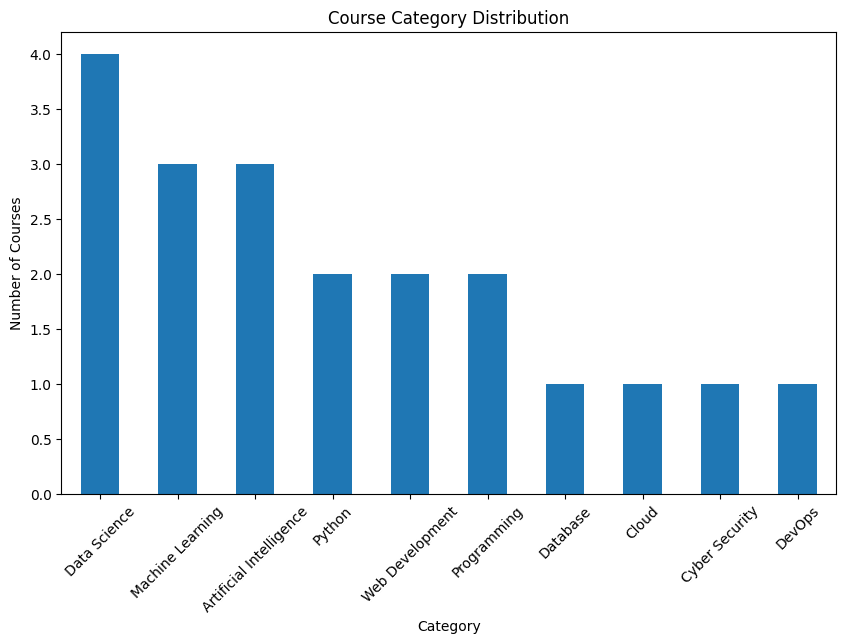

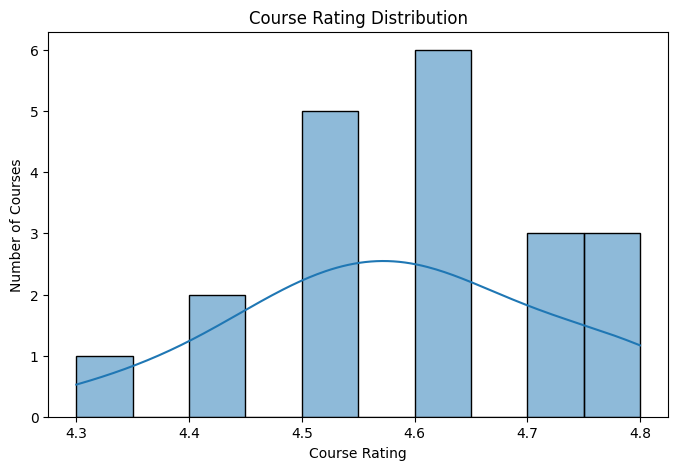

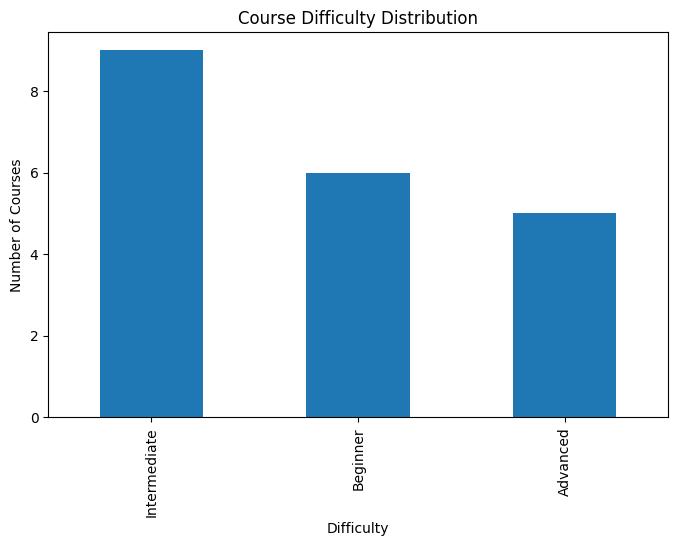


========== USER COURSE MATRIX ==========
course_id   C001  C002  C003  C004  C005  C006  C007  C008  C009  C010  C011  \
student_id                                                                     
S0001        0.0   2.0   0.0   4.0   0.0   0.0   2.0   3.0   0.0   4.0   4.0   
S0002        3.0   2.0   0.0   0.0   2.0   3.0   0.0   0.0   0.0   1.0   1.0   
S0003        1.0   1.0   0.0   0.0   0.0   2.0   1.0   0.0   5.0   0.0   0.0   
S0004        0.0   5.0   3.0   0.0   0.0   0.0   0.0   2.0   0.0   0.0   0.0   
S0005        4.0   0.0   0.0   0.0   5.0   0.0   2.0   3.0   0.0   0.0   2.0   

course_id   C012  C013  C014  C015  C016  C017  C018  C019  C020  
student_id                                                        
S0001        0.0   1.0   1.0   0.0   0.0   2.0   4.0   5.0   0.0  
S0002        0.0   3.0   0.0   0.0   0.0   2.0   0.0   0.0   1.0  
S0003        2.0   0.0   0.0   0.0   0.0   5.0   1.0   0.0   0.0  
S0004        2.0   0.0   2.0   5.0   5.0   0.0   0.0   0.0   0

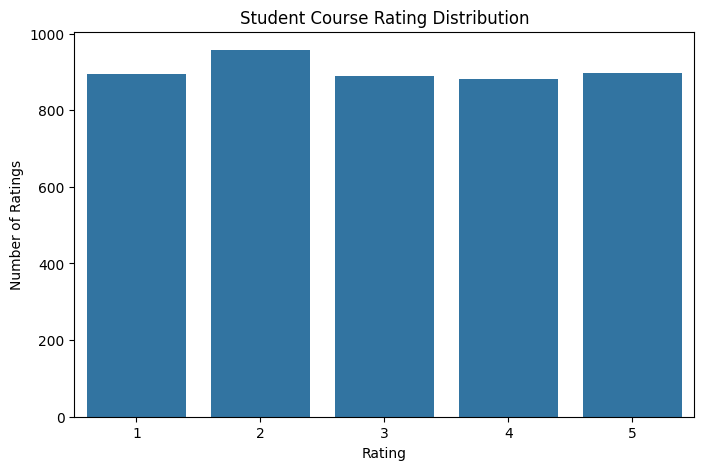

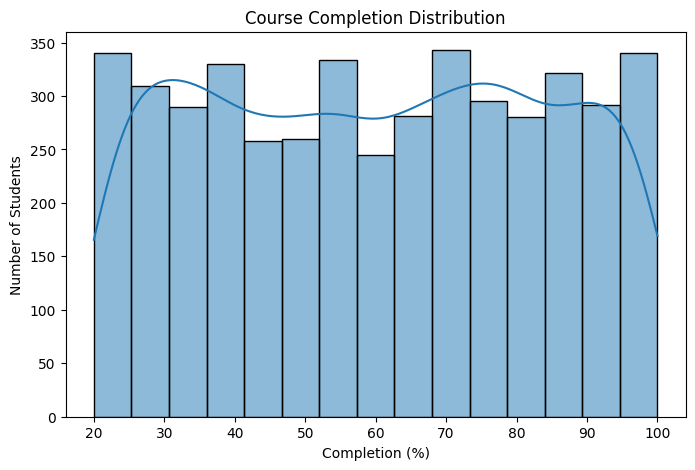



       PERSONALIZED E-LEARNING SYSTEM

Student ID: S0001
Interest: Machine Learning
Student Cluster: 1

Predicted Performance: 55.64


             TOP RECOMMENDED COURSES
1. Deep Learning --> Recommendation Score: 75.25%
2. Statistics for ML --> Recommendation Score: 42.16%
3. DevOps Fundamentals --> Recommendation Score: 35.0%
4. Artificial Intelligence --> Recommendation Score: 34.81%
5. React Development --> Recommendation Score: 32.25%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


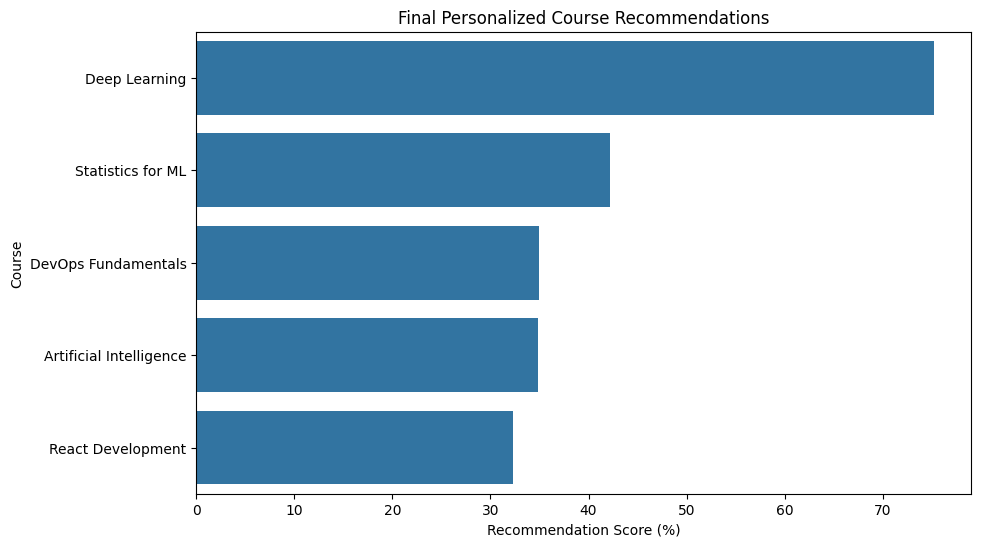

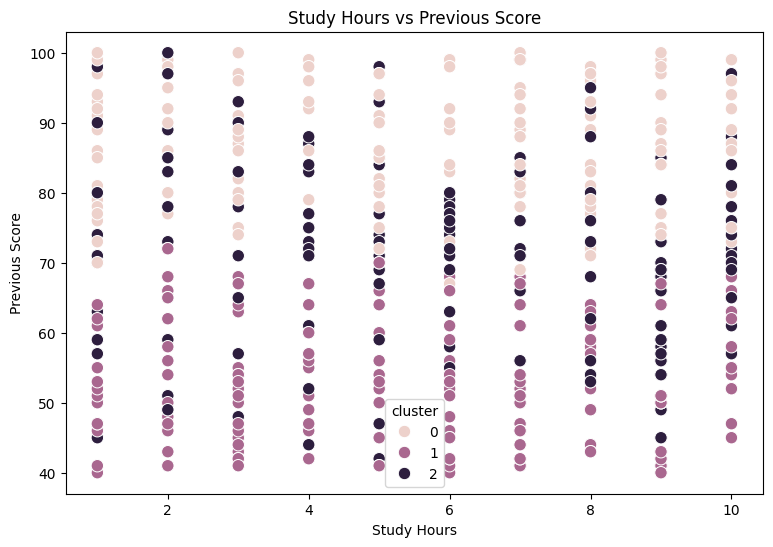

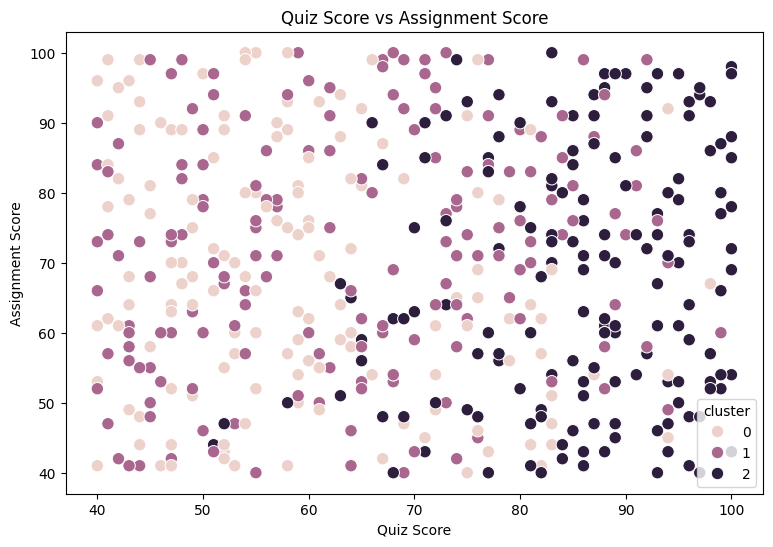

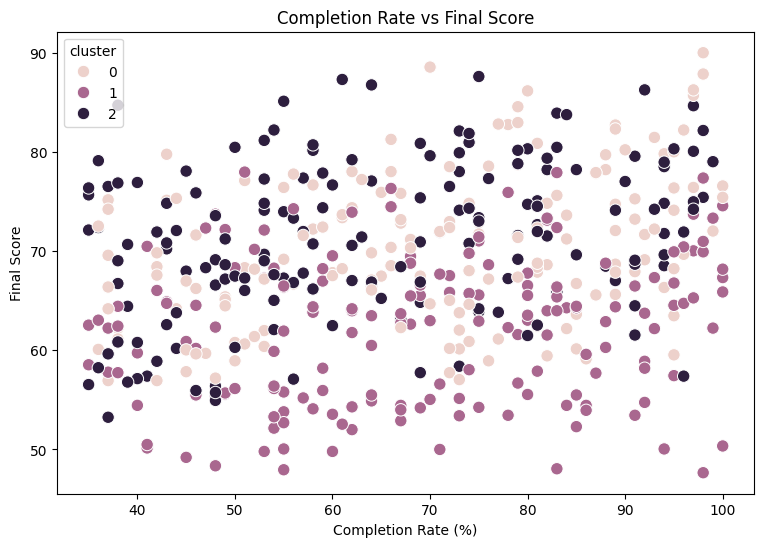

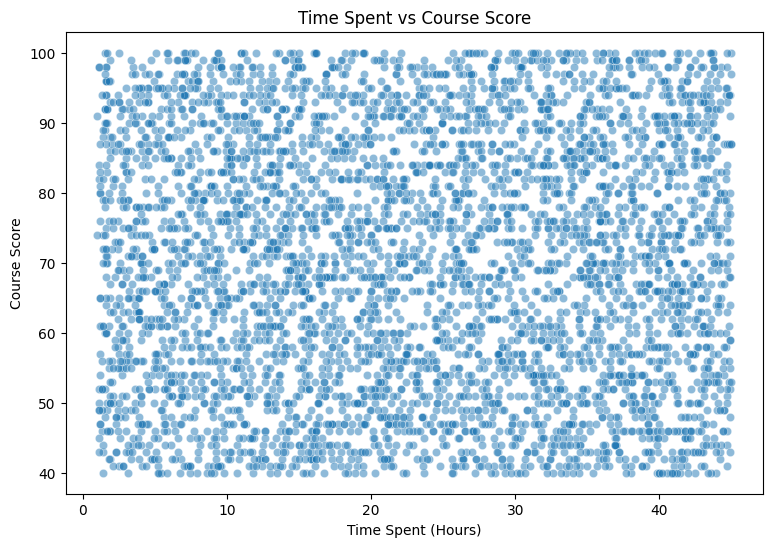

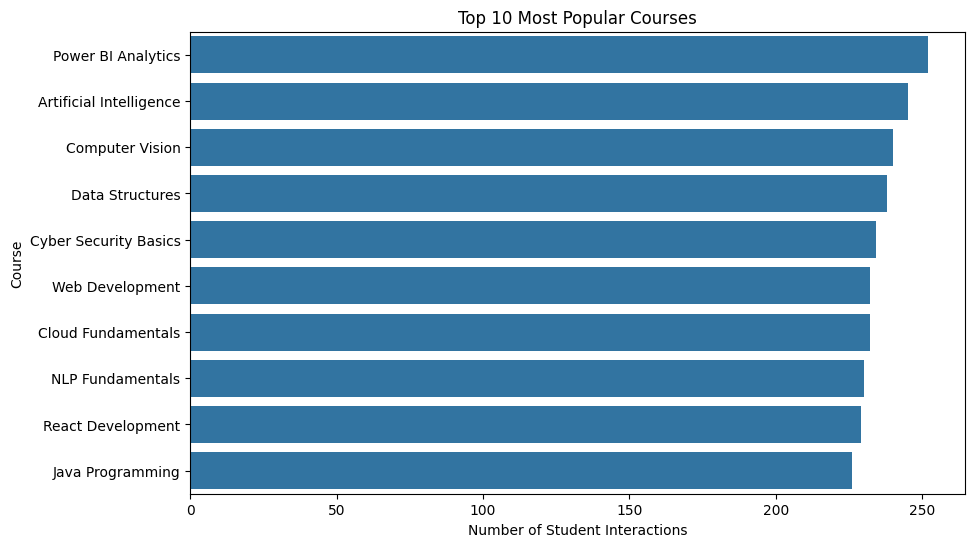

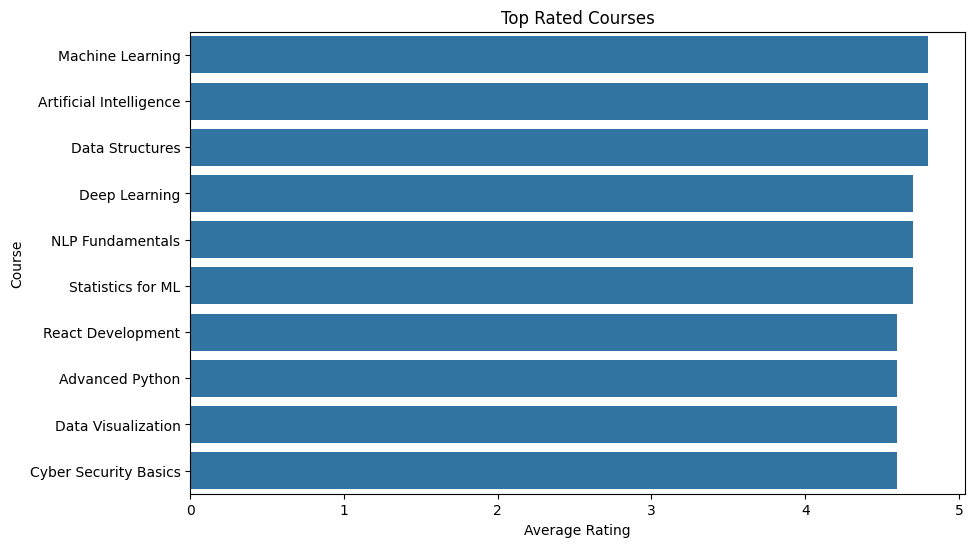



ALL ML PROCESSING COMPLETED SUCCESSFULLY
Combined dataset saved as:
combined_elearning_dataset.csv


In [28]:
# ============================================================
# E-LEARNING RECOMMENDATION ENGINE
# Personalized Learning Platform Using Machine Learning
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# 2. LOAD THREE DATASETS
# ============================================================

students = pd.read_csv("student_performance.csv")

courses = pd.read_csv("course_catalog.csv")

interactions = pd.read_csv(
    "student_course_interactions.csv"
)


print("\n==============================================")
print("        DATASET INFORMATION")
print("==============================================")

print(
    "Student Dataset Shape:",
    students.shape
)

print(
    "Course Dataset Shape:",
    courses.shape
)

print(
    "Interaction Dataset Shape:",
    interactions.shape
)


# ============================================================
# 3. DISPLAY DATASETS
# ============================================================

print("\n========== STUDENT DATA ==========")
print(students.head())

print("\n========== COURSE DATA ==========")
print(courses.head())

print("\n========== INTERACTION DATA ==========")
print(interactions.head())


# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

print("\n========== MISSING VALUES ==========")

print("\nStudent Dataset:")
print(students.isnull().sum())

print("\nCourse Dataset:")
print(courses.isnull().sum())

print("\nInteraction Dataset:")
print(interactions.isnull().sum())


# ============================================================
# 5. COMBINE STUDENT + INTERACTION DATA
# ============================================================

student_interactions = interactions.merge(
    students,
    on="student_id",
    how="left"
)


# ============================================================
# 6. COMBINE WITH COURSE DATA
# ============================================================

combined_data = student_interactions.merge(
    courses,
    on="course_id",
    how="left"
)


print("\n==============================================")
print("             COMBINED DATA")
print("==============================================")

print(combined_data.head())

print(
    "\nCombined Dataset Shape:",
    combined_data.shape
)


# ============================================================
# 7. BASIC STATISTICS
# ============================================================

print("\n========== STUDENT STATISTICS ==========")

print(students.describe())


print("\n========== COURSE STATISTICS ==========")

print(courses.describe())


print("\n========== INTERACTION STATISTICS ==========")

print(interactions.describe())


# ============================================================
# 8. VISUALIZATION 1
# STUDY HOURS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    students["study_hours"],
    bins=10,
    kde=True
)

plt.title(
    "Study Hours Distribution"
)

plt.xlabel(
    "Study Hours"
)

plt.ylabel(
    "Number of Students"
)

plt.show()


# ============================================================
# 9. VISUALIZATION 2
# PREVIOUS SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    students["previous_score"],
    bins=15,
    kde=True
)

plt.title(
    "Previous Score Distribution"
)

plt.xlabel(
    "Previous Score"
)

plt.ylabel(
    "Number of Students"
)

plt.show()


# ============================================================
# 10. VISUALIZATION 3
# QUIZ SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    students["quiz_score"],
    bins=15,
    kde=True
)

plt.title(
    "Quiz Score Distribution"
)

plt.xlabel(
    "Quiz Score"
)

plt.ylabel(
    "Number of Students"
)

plt.show()


# ============================================================
# 11. VISUALIZATION 4
# ASSIGNMENT SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    students["assignment_score"],
    bins=15,
    kde=True
)

plt.title(
    "Assignment Score Distribution"
)

plt.xlabel(
    "Assignment Score"
)

plt.ylabel(
    "Number of Students"
)

plt.show()


# ============================================================
# 12. VISUALIZATION 5
# COMPLETION RATE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    students["completion_rate"],
    bins=15,
    kde=True
)

plt.title(
    "Course Completion Rate Distribution"
)

plt.xlabel(
    "Completion Rate (%)"
)

plt.ylabel(
    "Number of Students"
)

plt.show()


# ============================================================
# 13. VISUALIZATION 6
# STUDENT INTEREST DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

students["interest"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Student Interest Distribution"
)

plt.xlabel(
    "Interest"
)

plt.ylabel(
    "Number of Students"
)

plt.xticks(
    rotation=45
)

plt.show()


# ============================================================
# 14. VISUALIZATION 7
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

correlation = students[
    [
        "study_hours",
        "previous_score",
        "quiz_score",
        "assignment_score",
        "completion_rate",
        "courses_completed"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Student Performance Correlation Heatmap"
)

plt.show()


# ============================================================
# 15. K-MEANS CLUSTERING
# ============================================================

cluster_features = [

    "study_hours",

    "previous_score",

    "quiz_score",

    "assignment_score",

    "completion_rate",

    "courses_completed"

]


X_cluster = students[
    cluster_features
]


# ============================================================
# 16. STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_cluster
)


# ============================================================
# 17. ELBOW METHOD
# ============================================================

inertia = []


for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(
        X_scaled
    )

    inertia.append(
        model.inertia_
    )


# ============================================================
# 18. VISUALIZATION 8
# ELBOW CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 8),
    inertia,
    marker="o"
)

plt.title(
    "Elbow Method for Optimal Clusters"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Inertia"
)

plt.show()


# ============================================================
# 19. APPLY K-MEANS
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)


students["cluster"] = kmeans.fit_predict(
    X_scaled
)


# ============================================================
# 20. SILHOUETTE SCORE
# ============================================================

silhouette = silhouette_score(
    X_scaled,
    students["cluster"]
)


print(
    "\nK-Means Silhouette Score:",
    round(silhouette, 3)
)


# ============================================================
# 21. CLUSTER SUMMARY
# ============================================================

cluster_summary = students.groupby(
    "cluster"
)[cluster_features].mean()


print(
    "\n========== CLUSTER SUMMARY =========="
)

print(
    cluster_summary
)


# ============================================================
# 22. VISUALIZATION 9
# STUDENT CLUSTERS
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=students,
    x="study_hours",
    y="previous_score",
    hue="cluster",
    s=100
)

plt.title(
    "Student Learning Clusters"
)

plt.xlabel(
    "Study Hours"
)

plt.ylabel(
    "Previous Score"
)

plt.show()


# ============================================================
# 23. VISUALIZATION 10
# CLUSTER DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

students[
    "cluster"
].value_counts().sort_index().plot(
    kind="bar"
)

plt.title(
    "Number of Students in Each Cluster"
)

plt.xlabel(
    "Cluster"
)

plt.ylabel(
    "Number of Students"
)

plt.show()


# ============================================================
# 24. CREATE FINAL PERFORMANCE SCORE
# ============================================================

students["final_score"] = (

    students["previous_score"] * 0.30

    + students["quiz_score"] * 0.25

    + students["assignment_score"] * 0.25

    + students["completion_rate"] * 0.10

    + students["study_hours"] * 1.0

)


# ============================================================
# 25. VISUALIZATION 11
# CLUSTER VS FINAL SCORE
# ============================================================

cluster_score = students.groupby(
    "cluster"
)["final_score"].mean()


plt.figure(figsize=(8, 5))

cluster_score.plot(
    kind="bar"
)

plt.title(
    "Average Final Score by Student Cluster"
)

plt.xlabel(
    "Cluster"
)

plt.ylabel(
    "Average Final Score"
)

plt.show()


# ============================================================
# 26. RANDOM FOREST
# PERFORMANCE PREDICTION
# ============================================================

X = students[
    [
        "study_hours",
        "previous_score",
        "quiz_score",
        "assignment_score",
        "completion_rate",
        "courses_completed"
    ]
]


y = students[
    "final_score"
]


# ============================================================
# 27. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)


# ============================================================
# 28. TRAIN RANDOM FOREST
# ============================================================

rf_model = RandomForestRegressor(

    n_estimators=200,

    random_state=42

)


rf_model.fit(
    X_train,
    y_train
)


# ============================================================
# 29. PREDICTION
# ============================================================

y_pred = rf_model.predict(
    X_test
)


# ============================================================
# 30. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)


rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


r2 = r2_score(
    y_test,
    y_pred
)


print(
    "\n=============================================="
)

print(
    "       RANDOM FOREST PERFORMANCE"
)

print(
    "=============================================="
)

print(
    "MAE:",
    round(mae, 3)
)

print(
    "RMSE:",
    round(rmse, 3)
)

print(
    "R2 Score:",
    round(r2, 3)
)


# ============================================================
# 31. VISUALIZATION 12
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel(
    "Actual Score"
)

plt.ylabel(
    "Predicted Score"
)

plt.title(
    "Actual vs Predicted Student Performance"
)

plt.show()


# ============================================================
# 32. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        rf_model.feature_importances_

})


importance = importance.sort_values(

    by="Importance",

    ascending=False

)


print(
    "\n========== FEATURE IMPORTANCE =========="
)

print(
    importance
)


# ============================================================
# 33. VISUALIZATION 13
# FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()


# ============================================================
# 34. TF-IDF
# COURSE TEXT PROCESSING
# ============================================================

courses["text"] = (

    courses["course_name"].fillna("")

    + " "

    + courses["category"].fillna("")

    + " "

    + courses["description"].fillna("")

)


tfidf = TfidfVectorizer(
    stop_words="english"
)


tfidf_matrix = tfidf.fit_transform(
    courses["text"]
)


print(
    "\nTF-IDF Matrix Shape:",
    tfidf_matrix.shape
)


# ============================================================
# 35. COSINE SIMILARITY
# ============================================================

cosine_matrix = cosine_similarity(
    tfidf_matrix
)


print(
    "Cosine Similarity Matrix Shape:",
    cosine_matrix.shape
)


# ============================================================
# 36. COURSE RECOMMENDATION FUNCTION
# ============================================================

def recommend_similar_courses(

    course_name,

    top_n=5

):

    matching_courses = courses[

        courses[
            "course_name"
        ].str.lower()
        ==
        course_name.lower()

    ]


    if matching_courses.empty:

        print(
            "Course not found"
        )

        return pd.DataFrame()


    index = matching_courses.index[0]


    scores = list(

        enumerate(
            cosine_matrix[index]
        )

    )


    scores = sorted(

        scores,

        key=lambda x: x[1],

        reverse=True

    )


    result = []


    for i, score in scores[1:top_n+1]:

        result.append({

            "course_name":
                courses.iloc[i]["course_name"],

            "category":
                courses.iloc[i]["category"],

            "difficulty":
                courses.iloc[i]["difficulty"],

            "rating":
                courses.iloc[i]["rating"],

            "similarity":
                round(score, 3)

        })


    return pd.DataFrame(
        result
    )


# ============================================================
# 37. TEST COURSE SIMILARITY
# ============================================================

print(
    "\n========== SIMILAR COURSES =========="
)


similar_courses = recommend_similar_courses(

    "Machine Learning",

    5

)


print(
    similar_courses
)


# ============================================================
# 38. VISUALIZATION 14
# COURSE CATEGORY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

courses[
    "category"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Course Category Distribution"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Number of Courses"
)

plt.xticks(
    rotation=45
)

plt.show()


# ============================================================
# 39. VISUALIZATION 15
# COURSE RATING DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(

    courses["rating"],

    bins=10,

    kde=True

)

plt.title(
    "Course Rating Distribution"
)

plt.xlabel(
    "Course Rating"
)

plt.ylabel(
    "Number of Courses"
)

plt.show()


# ============================================================
# 40. VISUALIZATION 16
# COURSE DIFFICULTY
# ============================================================

plt.figure(figsize=(8, 5))

courses[
    "difficulty"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Course Difficulty Distribution"
)

plt.xlabel(
    "Difficulty"
)

plt.ylabel(
    "Number of Courses"
)

plt.show()


# ============================================================
# 41. COLLABORATIVE FILTERING
# ============================================================

user_course_matrix = interactions.pivot_table(

    index="student_id",

    columns="course_id",

    values="rating",

    fill_value=0

)


print(
    "\n========== USER COURSE MATRIX =========="
)

print(
    user_course_matrix.head()
)


# ============================================================
# 42. STUDENT SIMILARITY
# ============================================================

student_similarity_matrix = cosine_similarity(

    user_course_matrix

)


student_similarity = pd.DataFrame(

    student_similarity_matrix,

    index=user_course_matrix.index,

    columns=user_course_matrix.index

)


# ============================================================
# 43. COLLABORATIVE RECOMMENDATION FUNCTION
# ============================================================

def collaborative_recommendation(

    student_id,

    top_n=5

):

    if student_id not in user_course_matrix.index:

        print(
            "Student not found"
        )

        return pd.DataFrame()


    similar_students = student_similarity[

        student_id

    ].sort_values(

        ascending=False

    )[1:6]


    scores = {}


    for (

        similar_student,

        similarity_score

    ) in similar_students.items():


        rated_courses = user_course_matrix.loc[

            similar_student

        ]


        for (

            course_id,

            rating

        ) in rated_courses.items():


            if rating > 0:

                scores[course_id] = (

                    scores.get(
                        course_id,
                        0
                    )

                    +

                    rating
                    *
                    similarity_score

                )


    recommendations = sorted(

        scores.items(),

        key=lambda x: x[1],

        reverse=True

    )


    result = []


    for course_id, score in recommendations:

        course_info = courses[

            courses[
                "course_id"
            ]
            ==
            course_id

        ]


        if not course_info.empty:

            result.append({

                "course_name":

                    course_info.iloc[0][
                        "course_name"
                    ],

                "category":

                    course_info.iloc[0][
                        "category"
                    ],

                "score":

                    round(
                        score,
                        3
                    )

            })


        if len(result) == top_n:

            break


    return pd.DataFrame(
        result
    )


# ============================================================
# 44. TEST COLLABORATIVE FILTERING
# ============================================================

print(
    "\n========== COLLABORATIVE RECOMMENDATIONS =========="
)


collab_result = collaborative_recommendation(

    "S0001",

    5

)


print(
    collab_result
)


# ============================================================
# 45. VISUALIZATION 17
# STUDENT RATING DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(

    data=interactions,

    x="rating"

)

plt.title(
    "Student Course Rating Distribution"
)

plt.xlabel(
    "Rating"
)

plt.ylabel(
    "Number of Ratings"
)

plt.show()


# ============================================================
# 46. VISUALIZATION 18
# COURSE COMPLETION DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(

    interactions["completion"],

    bins=15,

    kde=True

)

plt.title(
    "Course Completion Distribution"
)

plt.xlabel(
    "Completion (%)"
)

plt.ylabel(
    "Number of Students"
)

plt.show()


# ============================================================
# 47. INTEREST BASED RECOMMENDATION
# ============================================================

def recommend_by_interest(

    interest,

    top_n=5

):

    result = courses[

        courses[
            "category"
        ].str.contains(

            interest,

            case=False,

            na=False

        )

    ]


    result = result.sort_values(

        by="rating",

        ascending=False

    )


    return result[

        [
            "course_name",

            "category",

            "difficulty",

            "rating"

        ]

    ].head(top_n)


# ============================================================
# 48. HYBRID RECOMMENDATION
# ============================================================

def hybrid_recommendation(

    student_id,

    current_course,

    interest,

    top_n=5

):

    print("\n")

    print(
        "=" * 60
    )

    print(
        "       PERSONALIZED E-LEARNING SYSTEM"
    )

    print(
        "=" * 60
    )


    # --------------------------------------------------------
    # STUDENT INFORMATION
    # --------------------------------------------------------

    student_rows = students[

        students[
            "student_id"
        ]
        ==
        student_id

    ]


    if student_rows.empty:

        print(
            "Student not found"
        )

        return []


    student = student_rows.iloc[0]


    print(
        "\nStudent ID:",
        student_id
    )


    print(
        "Interest:",
        interest
    )


    print(
        "Student Cluster:",
        student["cluster"]
    )


    # --------------------------------------------------------
    # PERFORMANCE PREDICTION
    # --------------------------------------------------------

    student_features = student[

        [
            "study_hours",

            "previous_score",

            "quiz_score",

            "assignment_score",

            "completion_rate",

            "courses_completed"

        ]

    ].values.reshape(

        1,

        -1

    )


    predicted_score = rf_model.predict(

        student_features

    )[0]


    print(

        "\nPredicted Performance:",

        round(
            predicted_score,
            2
        )

    )


    # --------------------------------------------------------
    # CONTENT BASED
    # --------------------------------------------------------

    content_result = recommend_similar_courses(

        current_course,

        top_n

    )


    # --------------------------------------------------------
    # INTEREST BASED
    # --------------------------------------------------------

    interest_result = courses[

        courses[
            "category"
        ].str.contains(

            interest,

            case=False,

            na=False

        )

    ]


    # --------------------------------------------------------
    # COLLABORATIVE
    # --------------------------------------------------------

    collaborative_result = collaborative_recommendation(

        student_id,

        top_n

    )


    # --------------------------------------------------------
    # HYBRID SCORE
    # --------------------------------------------------------

    recommendation_scores = {}


    # CONTENT SCORE = 40%
    if not content_result.empty:

        for _, row in content_result.iterrows():

            course = row[
                "course_name"
            ]

            score = row[
                "similarity"
            ]


            recommendation_scores[course] = (

                recommendation_scores.get(
                    course,
                    0
                )

                +

                score * 0.40

            )


    # INTEREST SCORE = 25%
    for _, row in interest_result.iterrows():

        course = row[
            "course_name"
        ]


        recommendation_scores[course] = (

            recommendation_scores.get(
                course,
                0
            )

            +

            0.25

        )


    # COLLABORATIVE SCORE = 35%
    if not collaborative_result.empty:

        max_score = collaborative_result[
            "score"
        ].max()


        if max_score > 0:

            for _, row in collaborative_result.iterrows():

                course = row[
                    "course_name"
                ]


                normalized_score = (

                    row["score"]

                    /

                    max_score

                )


                recommendation_scores[course] = (

                    recommendation_scores.get(
                        course,
                        0
                    )

                    +

                    normalized_score
                    *
                    0.35

                )


    # --------------------------------------------------------
    # SORT FINAL RECOMMENDATIONS
    # --------------------------------------------------------

    final_recommendations = sorted(

        recommendation_scores.items(),

        key=lambda x: x[1],

        reverse=True

    )


    # --------------------------------------------------------
    # DISPLAY TOP 5
    # --------------------------------------------------------

    print("\n")

    print(
        "=" * 60
    )

    print(
        "             TOP RECOMMENDED COURSES"
    )

    print(
        "=" * 60
    )


    for rank, (

        course,

        score

    ) in enumerate(

        final_recommendations[
            :top_n
        ],

        start=1

    ):


        print(

            f"{rank}. {course}"

            f" --> Recommendation Score: "

            f"{round(score * 100, 2)}%"

        )


    return final_recommendations[
        :top_n
    ]


# ============================================================
# 49. RUN FINAL RECOMMENDATION
# ============================================================

final_result = hybrid_recommendation(

    student_id="S0001",

    current_course="Machine Learning",

    interest="Machine Learning",

    top_n=5

)


# ============================================================
# 50. VISUALIZATION 19
# FINAL RECOMMENDATION SCORE
# ============================================================

if final_result:

    recommendation_df = pd.DataFrame(

        final_result,

        columns=[

            "Course",

            "Recommendation_Score"

        ]

    )


    recommendation_df[
        "Recommendation_Score"
    ] = (

        recommendation_df[
            "Recommendation_Score"
        ]

        * 100

    )


    plt.figure(
        figsize=(10, 6)
    )


    sns.barplot(

        data=recommendation_df,

        x="Recommendation_Score",

        y="Course"

    )


    plt.title(

        "Final Personalized Course Recommendations"

    )


    plt.xlabel(

        "Recommendation Score (%)"

    )


    plt.ylabel(

        "Course"

    )


    plt.show()


# ============================================================
# 51. VISUALIZATION 20
# STUDY HOURS VS PREVIOUS SCORE
# ============================================================

plt.figure(figsize=(9, 6))


sns.scatterplot(

    data=students,

    x="study_hours",

    y="previous_score",

    hue="cluster",

    s=80

)


plt.title(

    "Study Hours vs Previous Score"

)


plt.xlabel(

    "Study Hours"

)


plt.ylabel(

    "Previous Score"

)


plt.show()


# ============================================================
# 52. VISUALIZATION 21
# QUIZ SCORE VS ASSIGNMENT SCORE
# ============================================================

plt.figure(figsize=(9, 6))


sns.scatterplot(

    data=students,

    x="quiz_score",

    y="assignment_score",

    hue="cluster",

    s=80

)


plt.title(

    "Quiz Score vs Assignment Score"

)


plt.xlabel(

    "Quiz Score"

)


plt.ylabel(

    "Assignment Score"

)


plt.show()


# ============================================================
# 53. VISUALIZATION 22
# COMPLETION RATE VS FINAL SCORE
# ============================================================

plt.figure(figsize=(9, 6))


sns.scatterplot(

    data=students,

    x="completion_rate",

    y="final_score",

    hue="cluster",

    s=80

)


plt.title(

    "Completion Rate vs Final Score"

)


plt.xlabel(

    "Completion Rate (%)"

)


plt.ylabel(

    "Final Score"

)


plt.show()


# ============================================================
# 54. VISUALIZATION 23
# TIME SPENT VS COURSE SCORE
# ============================================================

plt.figure(figsize=(9, 6))


sns.scatterplot(

    data=interactions,

    x="time_spent_hours",

    y="score",

    alpha=0.5

)


plt.title(

    "Time Spent vs Course Score"

)


plt.xlabel(

    "Time Spent (Hours)"

)


plt.ylabel(

    "Course Score"

)


plt.show()


# ============================================================
# 55. VISUALIZATION 24
# TOP 10 POPULAR COURSES
# ============================================================

course_popularity = (

    interactions[
        "course_id"
    ]

    .value_counts()

    .head(10)

)


popular_names = []


for course_id in course_popularity.index:

    course_name = courses[

        courses[
            "course_id"
        ]
        ==
        course_id

    ][
        "course_name"
    ].values[0]


    popular_names.append(
        course_name
    )


popularity_df = pd.DataFrame({

    "Course":
        popular_names,

    "Students":
        course_popularity.values

})


plt.figure(figsize=(10, 6))


sns.barplot(

    data=popularity_df,

    x="Students",

    y="Course"

)


plt.title(

    "Top 10 Most Popular Courses"

)


plt.xlabel(

    "Number of Student Interactions"

)


plt.ylabel(

    "Course"

)


plt.show()


# ============================================================
# 56. VISUALIZATION 25
# TOP RATED COURSES
# ============================================================

top_rated = courses.sort_values(

    by="rating",

    ascending=False

).head(10)


plt.figure(figsize=(10, 6))


sns.barplot(

    data=top_rated,

    x="rating",

    y="course_name"

)


plt.title(

    "Top Rated Courses"

)


plt.xlabel(

    "Average Rating"

)


plt.ylabel(

    "Course"

)


plt.show()


# ============================================================
# 57. SAVE COMBINED DATASET
# ============================================================

combined_data.to_csv(

    "combined_elearning_dataset.csv",

    index=False

)


print("\n")

print(
    "=" * 60
)

print(
    "ALL ML PROCESSING COMPLETED SUCCESSFULLY"
)

print(
    "=" * 60
)

print(
    "Combined dataset saved as:"
)

print(
    "combined_elearning_dataset.csv"
)